In [1]:
from langgraph.graph import StateGraph, START, END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import RemoveMessage
import os
from typing import Literal, Optional

In [2]:
from langchain_core.prompts import ChatPromptTemplate

In [3]:
load_dotenv()

True

In [4]:
chat_model = os.getenv('CHAT_MODEL')
llm = init_chat_model(model=chat_model)
llm.invoke('Hi')

AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 7, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFRAUvKqmr0nHaDSLqqgYPYGXbIyZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0263f-0c43-7ed0-83b9-2ef4df59978a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 12, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
class ChatState(MessagesState):
    summary: Optional[str] = None

In [6]:
checkpointer = InMemorySaver()

In [7]:
def chat_bot(state:ChatState):
    response = llm.invoke(state["messages"])
    return {"messages":[response]}

In [8]:
max_messages = 5

In [9]:
def route_messages(state: ChatState) -> Literal["summarization", "chat_bot"]:
    
    total_message = len(state["messages"])

    print(f"Total Messages: {total_message}")

    if total_message > max_messages:
        print('--------------- returned summarization -----------------')
        return "summarization"

    print('--------------- returned chatbot -----------------')
    return "chat_bot"

In [10]:
def summarization(state: ChatState):
    print('------------------ SUMMARIZATION ---------------')
    messages = state["messages"]
    old_messages = messages[:-max_messages]
    previous_summary = state.get("summary", "")

    if not old_messages:
        return {}

    conversation = "\n".join(
        f"{message.type}: {message.content}"
        for message in old_messages
    )

    if previous_summary:
        # Update existing summary with new messages
        summarization_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    "Update the existing summary by incorporating the new conversation messages. "
                    "Preserve all important facts, user preferences, names, decisions, and unfinished tasks "
                    "from both the previous summary and the new messages.",
                ),
                (
                    "human",
                    "Previous summary:\n{previous_summary}\n\n"
                    "New conversation messages to add:\n{conversation}",
                ),
            ]
        )
        prompt_value = summarization_prompt.invoke(
            {
                "previous_summary": previous_summary,
                "conversation": conversation,
            }
        )
    else:
        # Create initial summary
        summarization_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    "Summarize the conversation history concisely. "
                    "Preserve important facts, user preferences, names, "
                    "decisions, and unfinished tasks.",
                ),
                (
                    "human",
                    "Conversation history to summarize:\n\n{conversation}",
                ),
            ]
        )
        prompt_value = summarization_prompt.invoke(
            {"conversation": conversation}
        )

    summary_response = llm.invoke(prompt_value)

    return {
        "messages": [
            RemoveMessage(id=message.id)
            for message in old_messages
        ],
        "summary": summary_response.content,
    }

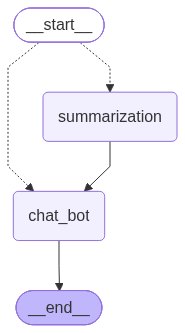

In [11]:
graph = StateGraph(ChatState)

graph.add_node("chat_bot", chat_bot)
graph.add_node("summarization", summarization)

graph.add_conditional_edges(
    START,
    route_messages,
    {
        "summarization": "summarization",
        "chat_bot": "chat_bot",
    },
)

graph.add_edge("summarization", "chat_bot")
graph.add_edge("chat_bot", END)

checkpointer_graph = graph.compile(checkpointer=checkpointer)

# Display
from IPython.display import Image, display
display(Image(checkpointer_graph.get_graph().draw_mermaid_png()))

In [12]:
print('To end: exit,q,quit')

_user_id = None 

while True:

    if not _user_id : 
        _user_id = input('User id: ')

    _input = input('User: ')
    
    if _input in ('q','quit','exit'):
        _user_id = None
        break
    
    message = {
        'messages':[
            {
                'role':'user',
                'content':_input
            }
        ]
    }

    config = {
        'configurable':{
            'thread_id':_user_id
        }
    }

    response  = checkpointer_graph.invoke(message,config)
    print('User: ', _input)
    print('AI: ',response["messages"][-1].content)

To end: exit,q,quit
Total Messages: 1
--------------- returned chatbot -----------------
User:  write 3 line
AI:  I can do that—what should the 3 lines be about?  
If you want, tell me a topic (love, motivation, school, funny, etc.) or the tone (poem, message, joke, etc.).
Total Messages: 3
--------------- returned chatbot -----------------
User:  another 2 line
AI:  Sure—here are 2 lines:

Keep going, even when it’s hard,  
Your future self will be proud.
Total Messages: 5
--------------- returned chatbot -----------------
User:  one more
AI:  Every step you take today builds strength for tomorrow.
Total Messages: 7
--------------- returned summarization -----------------
------------------ SUMMARIZATION ---------------
User:  add one more
AI:  Dream big and stay determined,  
You’ll reach your goals in time.
Total Messages: 7
--------------- returned summarization -----------------
------------------ SUMMARIZATION ---------------
User:  my name is tej
AI:  Hi Tej! 😊 What would you li